# SECTION 0

## Loading of neccessary packages

In [1]:
import os
import shap
import sys
import joblib
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.regression.mixed_linear_model import MixedLM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV, train_test_split, GroupShuffleSplit

In [2]:
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0]


# Data Preprocessing.

## SECTION 1.

### Calling and cleaning agricultural data.

#### Production data

In [3]:
production = pd.read_csv('Production.csv')
prod_use = production[production['Element'] == 'Production'].copy()

prod_pivot = prod_use.pivot_table(
    index='Year',
    columns='Item',
    values='Value'
).reset_index()

prod_cols = [c for c in prod_pivot.columns if c != 'Year']
prod_pivot['Production'] = prod_pivot[prod_cols].sum(axis=1)
prod_clean = prod_pivot[['Year', 'Production']].copy()
prod_clean.to_csv('Production_clean.csv', index=False)
#print(f"Shape: {prod_clean.shape}")
#print(prod_clean.head())

#### Area harvested data.

In [4]:
area = pd.read_csv('Area harvested.csv')
area_use = area[area['Element'] == 'Area harvested'].copy()

area_pivot = area_use.pivot_table(
    index='Year',
    columns='Item',
    values='Value'
).reset_index()

area_cols = [c for c in area_pivot.columns if c != 'Year']
area_pivot['Area'] = area_pivot[area_cols].sum(axis=1)
area_clean = area_pivot[['Year', 'Area']].copy()
area_clean.to_csv('Area_clean.csv', index=False)
#print(f"Shape: {area_clean.shape}")
#print(area_clean.head())

#### Fertilizer data.

In [5]:
fertilizer = pd.read_csv('Fertilizer.csv')
fert_use = fertilizer[fertilizer['Element'] == 'Agricultural Use'].copy()

fert_pivot = fert_use.pivot_table(
    index='Year',
    columns='Item',
    values='Value'
).reset_index()

fert_cols = [c for c in fert_pivot.columns if c != 'Year']
fert_pivot['Fertilizer'] = fert_pivot[fert_cols].sum(axis=1)
fert_clean = fert_pivot[['Year', 'Fertilizer']].copy()
fert_clean.to_csv('Fertilizer_clean.csv', index=False)
print(f"Shape: {fert_clean.shape}")
#print(fert_clean.head())

Shape: (14, 2)


#### Merging agricultural data.

In [6]:
df1 = pd.read_csv('Production_clean.csv')
df2 = pd.read_csv('Fertilizer_clean.csv')
df3 = pd.read_csv('Area_clean.csv')

df1['Year'] = df1['Year'].astype(int)
df2['Year'] = df2['Year'].astype(int)
df3['Year'] = df3['Year'].astype(int)

df1_filtered = df1[(df1['Year'] >= 1961) & (df1['Year'] <= 2023)]
df2_filtered = df2[(df2['Year'] >= 1961) & (df2['Year'] <= 2023)]
df3_filtered = df3[(df3['Year'] >= 1961) & (df3['Year'] <= 2023)]

merged = pd.merge(df1_filtered, df2_filtered, on='Year', how='outer')
merged = pd.merge(merged, df3_filtered, on='Year', how='outer')

merged = merged.sort_values('Year').reset_index(drop=True)
merged.to_csv('merged_data_2023.csv', index=False)
#print(merged.head())

#### Computing for yields in kilogram per hectare and adding it to the dataframe.

In [7]:
df = pd.read_csv('merged_data_2023.csv')

df['Yield_kg_per_ha'] = np.round((df['Production']*1000) / df['Area'],2)
df['Yield_kg_per_ha'] = df['Yield_kg_per_ha'].replace([np.inf, -np.inf], np.nan)

#print(df[['Year', 'Production', 'Area', 'Yield_kg_per_ha', 'Fertilizer']].head())
df.to_csv('Data_Yield.csv', index=False)

# SECTION 2.

## Calling regional dataset.

In [8]:
with open('regional_farmers.csv', 'r') as f:
    lines = f.readlines()

header_line = lines[2].strip().strip('"').strip("'")
headers = [h.strip().strip('"').strip("'") for h in header_line.split(',')]


data = []
for line in lines[3:]:
    if line.strip():
        clean_line = line.strip().strip('"').strip("'")
        parts = [p.strip().strip('"').strip("'") for p in clean_line.split(',')]
        if len(parts) == len(headers):
            data.append(parts)

farmers = pd.DataFrame(data, columns=headers)
farmers_maize = farmers[farmers['Types_of_most_cultivated_crop'] == 'Maize'].copy()
farmers_maize['All localities'] = pd.to_numeric(farmers_maize['All localities'], errors='coerce')
farmers_maize = farmers_maize.dropna(subset=['All localities'])

farmers_clean = farmers_maize[['Region', 'All localities']].copy()
farmers_clean.columns = ['region', 'farmers']

print(f"Number of regions with data: {len(farmers_clean)}")
#print(farmers_clean)
farmers_clean.to_csv('regional_farmers_clean.csv', index=False)

Number of regions with data: 16


#### Computing for region contribution using number of farmer in each region and merging it agricultural dataframe.

In [9]:
maize_nat = pd.read_csv('Data_Yield.csv')
farmers_reg = pd.read_csv('regional_farmers_clean.csv')

total_farmers = farmers_reg['farmers'].sum()
farmers_reg['regional_share'] = farmers_reg['farmers'] / total_farmers

regional_rows = []

for _, region_row in farmers_reg.iterrows():
    region = region_row['region']
    share = region_row['regional_share']

    for _, year_row in maize_nat.iterrows():
        year = int(year_row['Year'])
        prod_nat = year_row['Production']
        area_nat = year_row['Area']
        yield_nat = year_row['Yield_kg_per_ha']
        fert_nat = year_row['Fertilizer']

        prod_reg = prod_nat * share
        area_reg = area_nat * share
        fert_reg = fert_nat * share
        yield_reg = (prod_reg / area_reg) * 1000 if area_reg > 0 else np.nan

        regional_rows.append({
            'region': region,
            'year': year,
            'Production': prod_reg,
            'Area': area_reg,
            'Yield_kg_per_ha': yield_reg,
            'Fertilizer': fert_reg,
            'Regional_share': share
        })

regional_df = pd.DataFrame(regional_rows)
print(f"Created dataset with {regional_df.shape[0]} rows")
print(f"Years: {regional_df['year'].min()} – {regional_df['year'].max()}")
print(f"Regions: {regional_df['region'].nunique()}")
#print(regional_df.head())
regional_df.to_csv('Ghana_Maize_Regional_2023.csv', index=False)

Created dataset with 224 rows
Years: 2010 – 2023
Regions: 16


# SECTION 3

## Calling and clearning climatic data.

### Rainfall data.

In [10]:
df_rain = pd.read_csv('Rainfall.csv', skiprows=9, usecols=lambda x: x != 'Unnamed: 0')
df_rain.columns = df_rain.columns.str.strip()
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_rain['Rainfall'] = df_rain[months].sum(axis=1)

#print(df_rain[['YEAR', 'LAT', 'LON', 'Rainfall']].head())

#### Relative humidity data.

In [11]:
df_Humidity = pd.read_csv('Relative Humidity.csv', skiprows=9, usecols=lambda x: x != 'Unnamed: 0')
df_Humidity.columns = df_Humidity.columns.str.strip()
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_Humidity['Humidity'] = df_Humidity[months].sum(axis=1)

#print(df_Humidity[['YEAR', 'LAT', 'LON', 'Humidity']].head())

#### Root zone soil data.

In [12]:
df_soil = pd.read_csv('RootZoneSoil.csv', skiprows=9, usecols=lambda x: x != 'Unnamed: 0')
df_soil.columns = df_soil.columns.str.strip()
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_soil['Root_zone_soil'] = df_soil[months].sum(axis=1)

#print(df_soil[['YEAR', 'LAT', 'LON', 'Root_zone_soil']].head())

#### Percipitation as temperature data.

In [13]:
df_temperature = pd.read_csv('Temperature.csv', skiprows=9, usecols=lambda x: x != 'Unnamed: 0')
df_temperature.columns = df_temperature.columns.str.strip()
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_temperature['Temperature'] = df_temperature[months].sum(axis=1)

#print(df_temperature[['YEAR', 'LAT', 'LON', 'Temperature']].head())

### Merging climatic data.

In [14]:
def get_ghana_region_16(lat, lon):
    # NORTHERN ZONE (Lat >= 8.8)
    if lat >= 10.3:
        return "Upper West" if lon < -1.6 else "Upper East"
    elif lat >= 9.8:
        return "North East"
    elif lat >= 8.8:
        if lon < -1.5: return "Savannah"
        elif lon < -0.5: return "Northern"
        else: return "North East"

    # MIDDLE ZONE (Lat 6.5 to 8.8)
    elif lat >= 7.5:
        if lon < -2.0: return "Bono"
        elif lon < -1.0: return "Bono East"
        else: return "Oti"
    elif lat >= 6.5:
        if lon < -2.0: return "Western North"
        elif lon < -1.0: return "Ahafo"
        elif lon < -0.2: return "Ashanti"
        else: return "Eastern"

    # SOUTHERN ZONE (Lat < 6.5)
    else:
        if lon < -1.8: return "Western"
        if lon > 0.5: return "Volta"
        # Narrowing down the Greater Accra / Central border
        if lat < 6.0 and lon > -0.5: return "Greater Accra"
        return "Central"

df_rain['region'] = df_rain.apply(lambda x: get_ghana_region_16(x['LAT'], x['LON']), axis=1)
df_Humidity['region'] = df_Humidity.apply(lambda x: get_ghana_region_16(x['LAT'], x['LON']), axis=1)
df_soil['region'] = df_soil.apply(lambda x: get_ghana_region_16(x['LAT'], x['LON']), axis=1)
df_temperature['region'] = df_temperature.apply(lambda x: get_ghana_region_16(x['LAT'], x['LON']), axis=1)

df_regional_rain = df_rain.groupby(['region', 'YEAR'])['Rainfall'].mean().reset_index()
df_regional_Humidity = df_Humidity.groupby(['region', 'YEAR'])['Humidity'].mean().reset_index()
df_regional_soil = df_soil.groupby(['region', 'YEAR'])['Root_zone_soil'].mean().reset_index()
df_regional_temperature = df_temperature.groupby(['region', 'YEAR'])['Temperature'].mean().reset_index()

df_regional_Humidity.rename(columns={'YEAR': 'year'}, inplace=True)
df_regional_rain.rename(columns={'YEAR': 'year'}, inplace=True)
df_regional_soil.rename(columns={'YEAR': 'year'}, inplace=True)
df_regional_temperature.rename(columns={'YEAR': 'year'}, inplace=True)

#### Comfirm the regions.

In [15]:
df_temperature['region'] = df_temperature.apply(lambda x: get_ghana_region_16(x['LAT'], x['LON']), axis=1)
print(f"Unique regions found: {df_temperature['region'].nunique()}")
print(df_temperature['region'].unique())

Unique regions found: 16
['North East' 'Upper East' 'Upper West' 'Central' 'Western'
 'Greater Accra' 'Volta' 'Ashanti' 'Ahafo' 'Western North' 'Eastern' 'Oti'
 'Bono East' 'Bono' 'Northern' 'Savannah']


#### Merging agricultural data and climatic data.

In [16]:
final_merged_data = regional_df.merge(
    df_regional_rain, on=['region', 'year'], how='left'
).merge(
    df_regional_temperature, on=['region', 'year'], how='left'
).merge(
    df_regional_soil, on=['region', 'year'], how='left'
).merge(
    df_regional_Humidity, on=['region', 'year'], how='left'
)

final_merged_data.to_csv('Ghana_Maize_2023.csv', index=False)

# SECTION 4

#### Computing for coreelation.

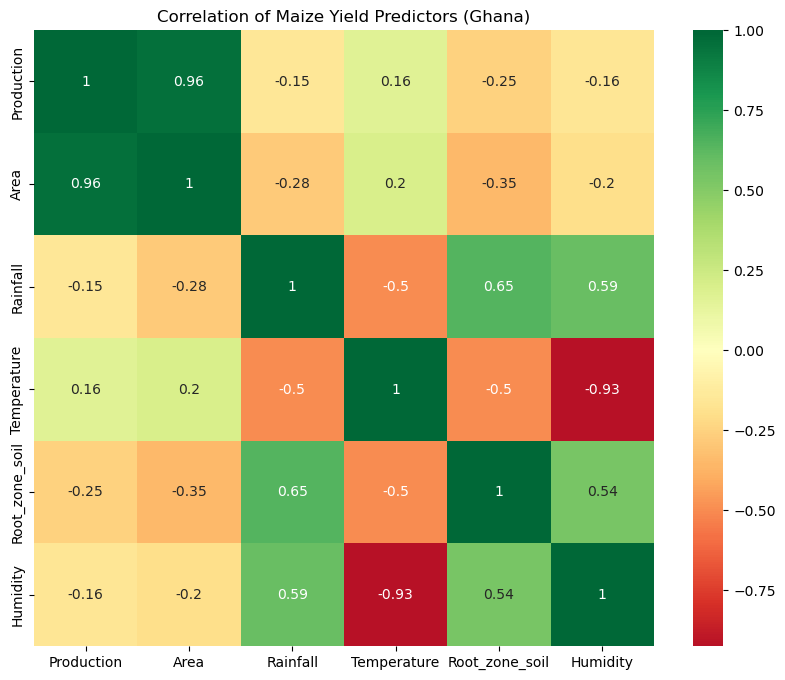

In [17]:
cols_to_corr = ['Production', 'Area', 'Rainfall', 'Temperature', 'Root_zone_soil', 'Humidity']
subset_df = final_merged_data[cols_to_corr]
corr_matrix = subset_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Correlation of Maize Yield Predictors (Ghana)")
#plt.savefig('correlation_check.png')
plt.show()

# SECTION 5

#### Computimg and plotting skewness of yields.

Skewness of yield: 0.2897


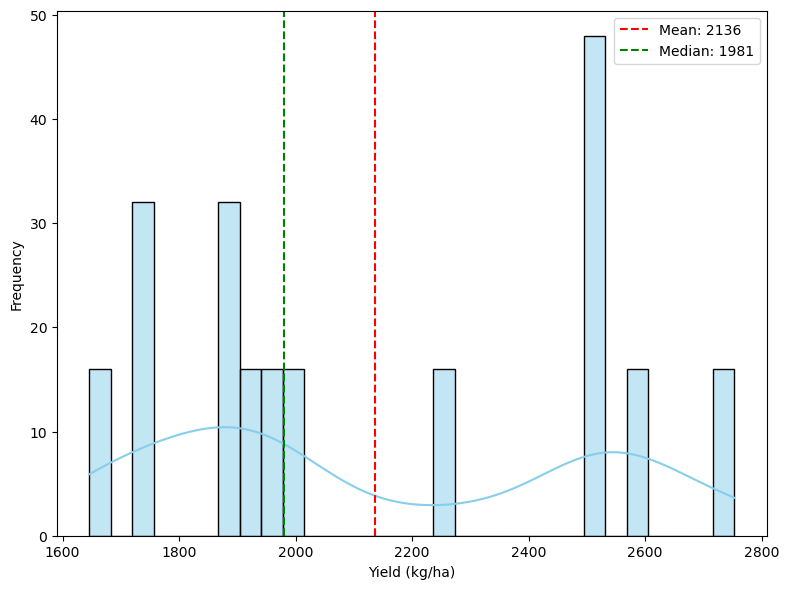

In [18]:
dak = pd.read_csv('Ghana_Maize_2023.csv')
skewness = dak['Yield_kg_per_ha'].skew()
print(f"Skewness of yield: {skewness:.4f}")


plt.figure(figsize=(8,6))
sns.histplot(dak['Yield_kg_per_ha'], bins=30, kde=True, color='skyblue')
plt.axvline(dak['Yield_kg_per_ha'].mean(), color='red', linestyle='--', label=f"Mean: {dak['Yield_kg_per_ha'].mean():.0f}")
plt.axvline(dak['Yield_kg_per_ha'].median(), color='green', linestyle='--', label=f"Median: {dak['Yield_kg_per_ha'].median():.0f}")
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
#plt.title(f'Yield Distribution (Skewness = {skewness:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('yield_skewness_check.png')
plt.show()

# Model Fitting.

# Section 5

#### Setting features for fitting the models.

In [19]:
features_1 = ['Regional_share' ,'Fertilizer', 'Rainfall', 'Temperature']
X_1 = dak[features_1]
y_1 = dak['Yield_kg_per_ha']

features_2 = ['Fertilizer', 'Rainfall', 'Temperature']
X_2 = dak[features_2]
y_2 = dak['Yield_kg_per_ha']

#### Splitting the data into trainning and test data.

In [20]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

#### Fitting Random forest model for the first time.

--- Random Forest Performance rf_1 ---
R-squared: 0.7803
RMSE: 0.18 kg/ha
MAE: 0.15 kg/ha


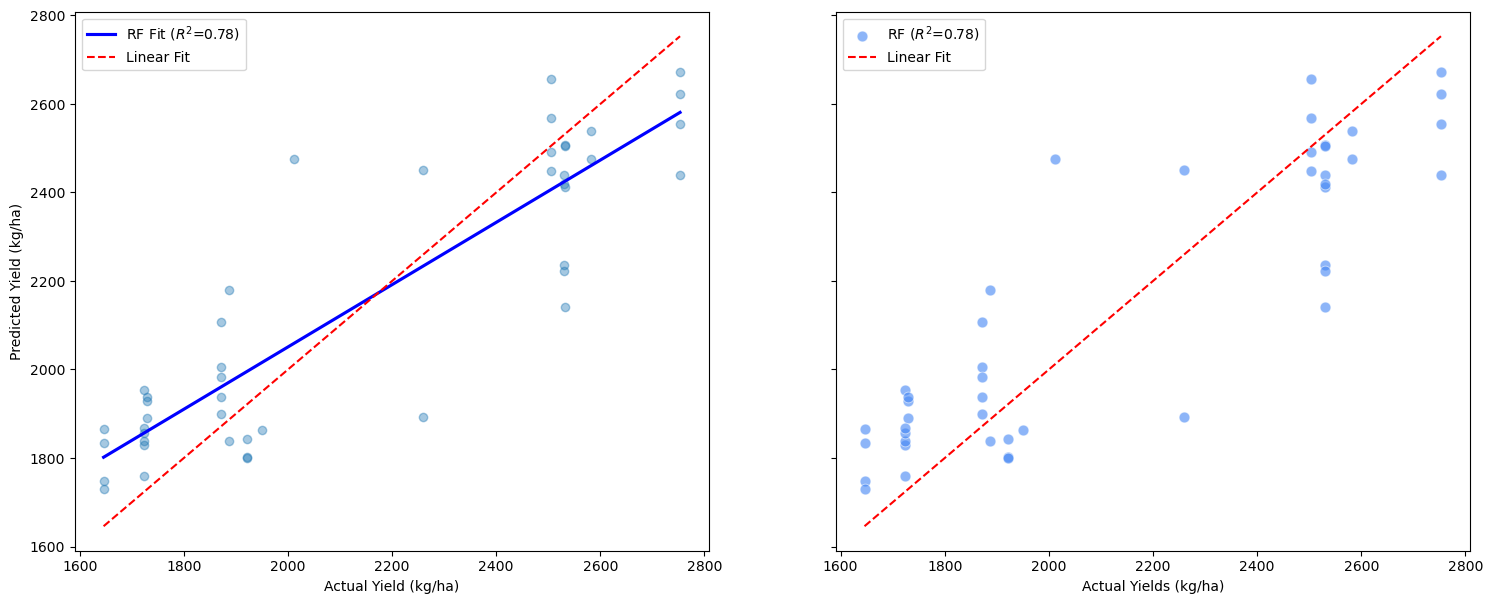

In [21]:
rf_model_1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_1.fit(X_train_1, y_train_1)

rf_predictions_1 = rf_model_1.predict(X_test_1)

mae = mean_absolute_error(y_test_1, rf_predictions_1)
rmse = np.sqrt(mean_squared_error(y_test_1, rf_predictions_1))
r2_rf = r2_score(y_test_1, rf_predictions_1)
print(f"--- Random Forest Performance rf_1 ---")
print(f"R-squared: {r2_rf:.4f}")
print(f"RMSE: {rmse/1000:.2f} kg/ha")
print(f"MAE: {mae/1000:.2f} kg/ha")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.regplot(x=y_test_1, y=rf_predictions_1, ax=ax1,
            scatter_kws={'alpha': 0.4},
            line_kws={'color': 'blue', 'label': f'RF Fit ($R^2$={r2_rf:.2f})'},
            ci=None)


all_vals = np.concatenate([y_test_1, rf_predictions_1])
ax1.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
         color='red', linestyle='--', label='Linear Fit')

ax1.set_xlabel('Actual Yield (kg/ha)')
ax1.set_ylabel('Predicted Yield (kg/ha)')
ax1.legend()

sns.scatterplot(x=y_test_1, y=rf_predictions_1, ax=ax2,
                alpha=0.6, color='#4285F4', s=60, label=f'RF ($R^2$={r2_rf:.2f})')

min_v, max_v = all_vals.min(), all_vals.max()
ax2.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', label='Linear Fit')


ax2.set_xlabel('Actual Yields (kg/ha)')
ax2.set_yticklabels([])
ax2.legend()
#plt.tight_layout()
plt.savefig('RF_r=0.78.png')
plt.show()

#### Fitting Gradient boosting model for the first time.

--- Gradient Boosting Performance gb_1---
R-squared: 0.8205
RMSE: 0.17 kg/ha
MAE: 0.14 kg/ha


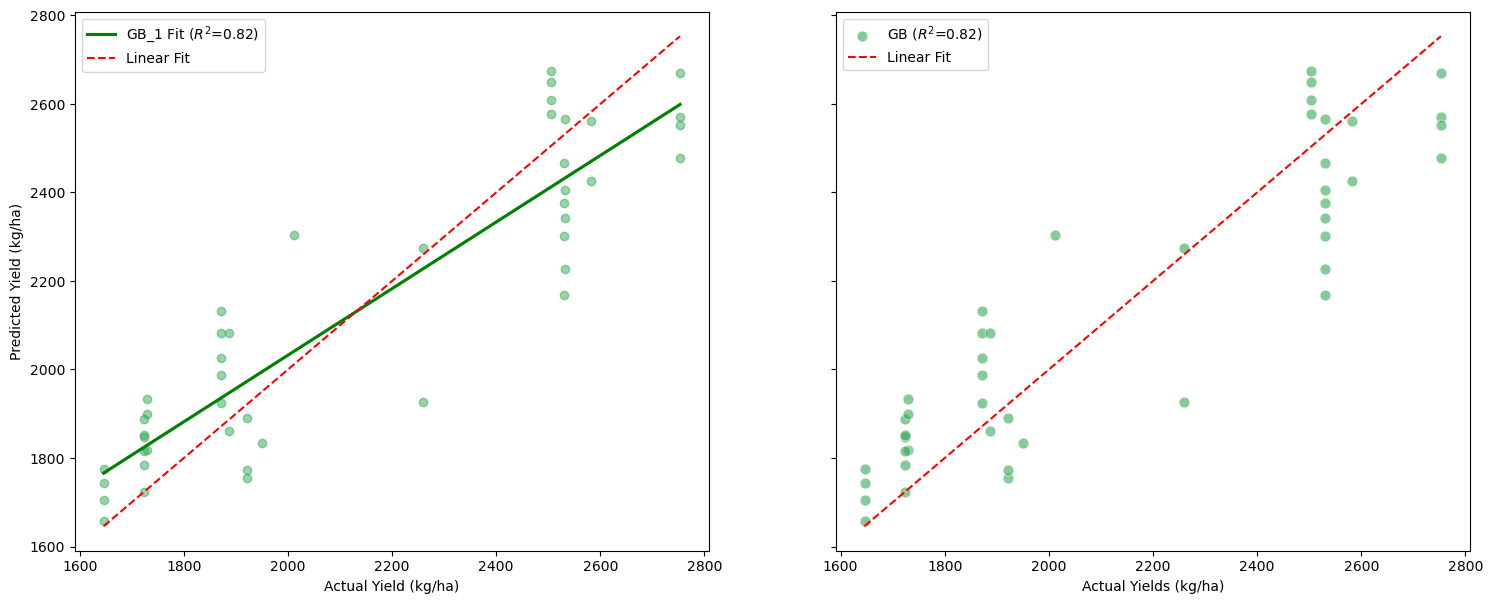

In [22]:
gb_model_1 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model_1.fit(X_train_1, y_train_1)

gb_predictions_1 = gb_model_1.predict(X_test_1)

mae = mean_absolute_error(y_test_1, gb_predictions_1)
rmse = np.sqrt(mean_squared_error(y_test_1, gb_predictions_1))
r2_gb = r2_score(y_test_1, gb_predictions_1)
print(f"--- Gradient Boosting Performance gb_1---")
print(f"R-squared: {r2_gb:.4f}")
print(f"RMSE: {rmse/1000:.2f} kg/ha")
print(f"MAE: {mae/1000:.2f} kg/ha")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.regplot(x=y_test_1, y=gb_predictions_1, ax=ax1,
            scatter_kws={'alpha':0.5}, color="#34A853", 
            line_kws={'color':'green', 'label':f'GB_1 Fit ($R^2$={r2_gb:.2f})'},
           ci=None)

all_vals = np.concatenate([y_test_1, gb_predictions_1])
ax1.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
         color='red', linestyle='--', label='Linear Fit')

ax1.set_xlabel('Actual Yield (kg/ha)')
ax1.set_ylabel('Predicted Yield (kg/ha)')
ax1.legend()

sns.scatterplot(x=y_test_1, y=gb_predictions_1, ax=ax2,
                alpha=0.6, color="#34A853", s=60, label=f'GB ($R^2$={r2_gb:.2f})')

min_v, max_v = all_vals.min(), all_vals.max()
ax2.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', label='Linear Fit')


ax2.set_xlabel('Actual Yields (kg/ha)')
ax2.set_yticklabels([])
ax2.legend()
#plt.tight_layout()
plt.savefig('GB_r=0.82.png')
plt.show()

#### Fitting both models together (Gradient boosting and Random Forest models).

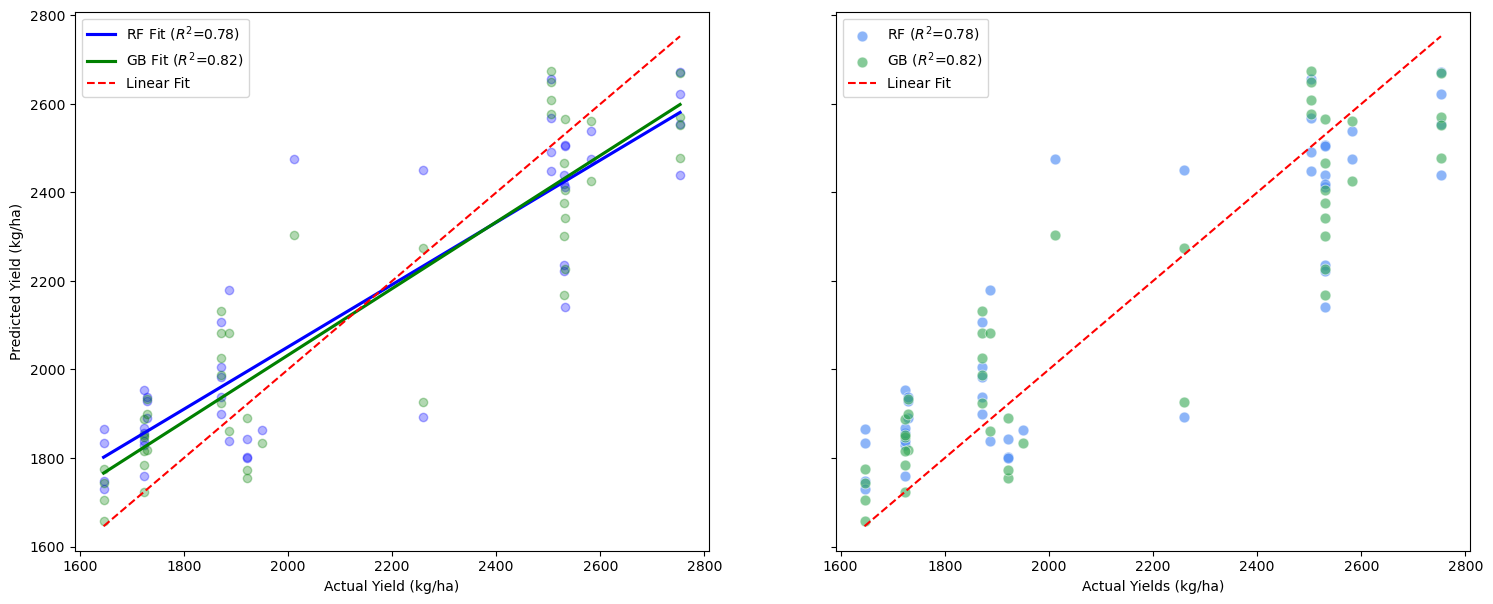

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.regplot(x=y_test_1, y=rf_predictions_1, ax=ax1,
            scatter_kws={'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'blue', 'label':f'RF Fit ($R^2$={r2_rf:.2f})'},
            ci=None)
sns.regplot(x=y_test_1, y=gb_predictions_1, ax=ax1,
            scatter_kws={'alpha':0.3, 'color':'green'}, 
            line_kws={'color':'green', 'label':f'GB Fit ($R^2$={r2_gb:.2f})'},
            ci=None)


all_vals = np.concatenate([y_test_1, rf_predictions_1, gb_predictions_1])
ax1.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
         color='red', linestyle='--', label='Linear Fit')

ax1.set_xlabel('Actual Yield (kg/ha)')
ax1.set_ylabel('Predicted Yield (kg/ha)')
ax1.legend()

sns.scatterplot(x=y_test_1, y=rf_predictions_1, ax=ax2,
                alpha=0.6, color="#4285F4", s=60, label=f'RF ($R^2$={r2_rf:.2f})')
sns.scatterplot(x=y_test_1, y=gb_predictions_1, ax=ax2,
                alpha=0.6, color="#34A853", s=60, label=f'GB ($R^2$={r2_gb:.2f})')

min_v, max_v = all_vals.min(), all_vals.max()
ax2.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', label='Linear Fit')


ax2.set_xlabel('Actual Yields (kg/ha)')
ax2.set_yticklabels([])
ax2.legend()
#plt.tight_layout()
plt.savefig('RF_r=0.78 and GB_r=0.82.png')
plt.show()

# SECTION 6.

#### Refitting model without regional contribution.

#### Refitting the radom forest model.

--- Random Forest Performance rf_2 ---
R-squared: 0.7348
RMSE: 0.20 kt (kilo-tonnes)
MAE: 0.16 kt (kilo-tonnes)


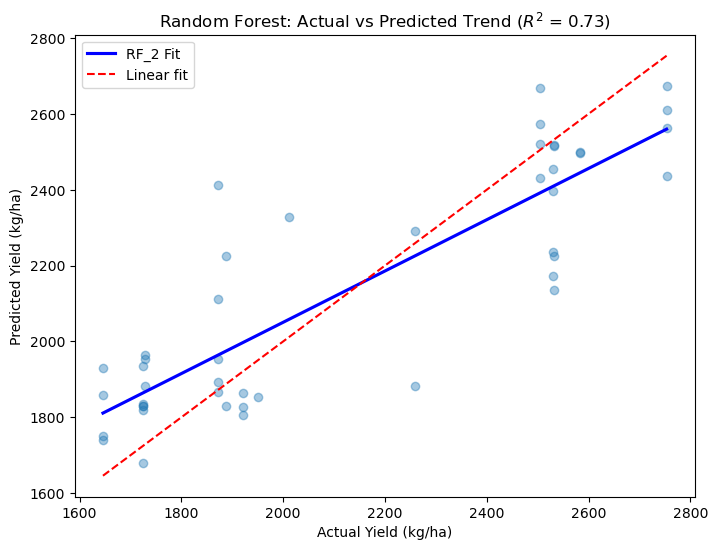

In [24]:
rf_model_2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_2.fit(X_train_2, y_train_2)

rf_predictions_2 =rf_model_2.predict(X_test_2)

mae = mean_absolute_error(y_test_2, rf_predictions_2)
rmse = np.sqrt(mean_squared_error(y_test_2, rf_predictions_2))
r2_rf_2 = r2_score(y_test_2, rf_predictions_2)
print(f"--- Random Forest Performance rf_2 ---")
print(f"R-squared: {r2_rf_2:.4f}")
print(f"RMSE: {rmse/1000:.2f} kt (kilo-tonnes)")
print(f"MAE: {mae/1000:.2f} kt (kilo-tonnes)")

plt.figure(figsize=(8, 6))
sns.regplot(x=y_test_2, y=rf_predictions_2, 
            scatter_kws={'alpha':0.4}, 
            line_kws={'color':'blue', 'label':'RF_2 Fit'},
           ci=None)
all_vals = np.concatenate([y_test_2, rf_predictions_2])
plt.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()], 
         color='red', linestyle='--', label='Linear fit')
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title(f'Random Forest: Actual vs Predicted Trend ($R^2$ = {r2_rf_2:.2f})')
plt.legend()
plt.show()

#### Refitting the gradient boosting model.

--- Gradient Boosting Performance gb_2---
R-squared: 0.7232
RMSE: 0.21 kt
MAE: 0.16 kt


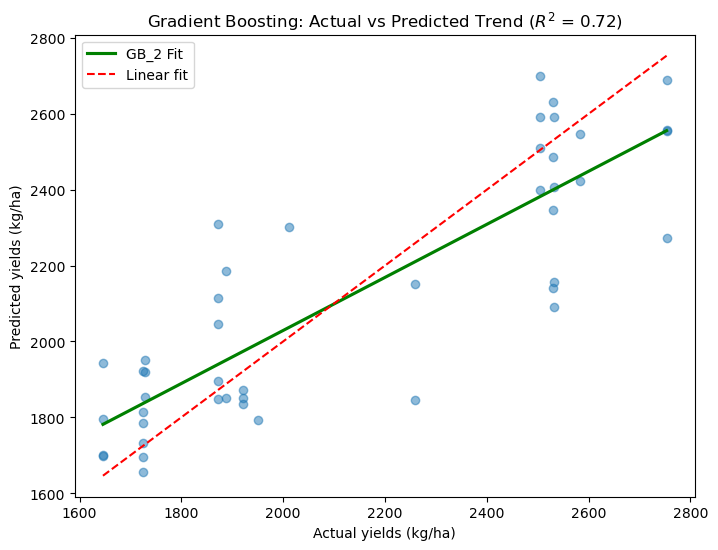

In [25]:
gb_model_2 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model_2.fit(X_train_2, y_train_2)

gb_predictions_2 = gb_model_2.predict(X_test_2)

mae = mean_absolute_error(y_test_2, gb_predictions_2)
rmse = np.sqrt(mean_squared_error(y_test_2, gb_predictions_2))
r2_gb_2 = r2_score(y_test_2, gb_predictions_2)
print(f"--- Gradient Boosting Performance gb_2---")
print(f"R-squared: {r2_gb_2:.4f}")
print(f"RMSE: {rmse/1000:.2f} kt")
print(f"MAE: {mae/1000:.2f} kt")

plt.figure(figsize=(8, 6))
sns.regplot(x=y_test_2, y=gb_predictions_2, 
            scatter_kws={'alpha':0.5}, 
            line_kws={'color':'green', 'label':'GB_2 Fit'},
           ci=None)
all_vals = np.concatenate([y_test_2, gb_predictions_2])
min_val, max_val = all_vals.min(), all_vals.max()
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linestyle='--', label='Linear fit')
plt.xlabel('Actual yields (kg/ha)')
plt.ylabel('Predicted yields (kg/ha)')
plt.title(f'Gradient Boosting: Actual vs Predicted Trend ($R^2$ = {r2_gb_2:.2f})')
plt.legend()
plt.show()

# SECTION 7.

#### Computing for metrics, feature importance and plotting for the first fitted Random Forest.

--- Random forest Performance rf_1---
R-squared: 0.7803
RMSE: 0.18 kg/ha
MAE: 0.15 kg/ha

--- Model Summary: Feature Importance rf_1---
Fertilizer        0.423800
Rainfall          0.378768
Temperature       0.106790
Regional_share    0.090641
dtype: float64


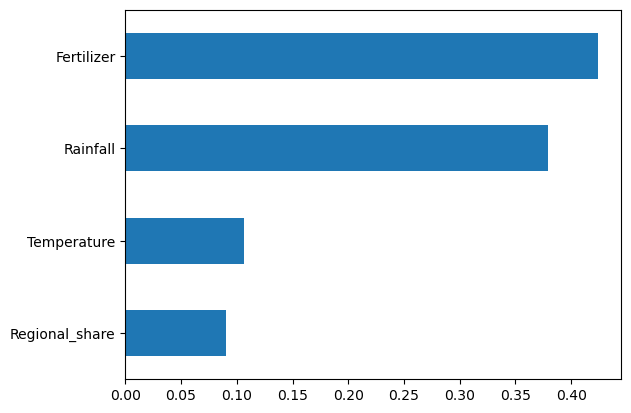

In [26]:
mae = mean_absolute_error(y_test_1, rf_predictions_1)
rmse = np.sqrt(mean_squared_error(y_test_1, rf_predictions_1))
r2 = r2_score(y_test_1, rf_predictions_1)
print(f"--- Random forest Performance rf_1---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse/1000:.2f} kg/ha")
print(f"MAE: {mae/1000:.2f} kg/ha")
 
print("\n--- Model Summary: Feature Importance rf_1---")
importances = pd.Series(rf_model_1.feature_importances_, index=features_1)
print(importances.sort_values(ascending=False))

importances = pd.Series(rf_model_1.feature_importances_, index=rf_model_1.feature_names_in_)
importances.sort_values().plot(kind='barh') #title='Feature Importance Summary')
#plt.savefig('feature_important_RF.png')
plt.show()

In [27]:
df_preview = pd.DataFrame({'Actual': y_test_2, 'Predicted': gb_predictions_2})
#print(df_preview)

# SECTION 8.

#### Computing for metrics, feature importance and plotting for the first fitted Gradient Boosting momdel.

--- Gradient Boosting Performance gb_1---
R-squared: 0.8205
RMSE: 0.17 kg/ha
MAE: 0.14 kg/ha

--- Model Summary: Feature Importance gb_1---
Fertilizer        0.434363
Rainfall          0.351715
Temperature       0.115697
Regional_share    0.098225
dtype: float64

Final Training Deviance: 4721.1224


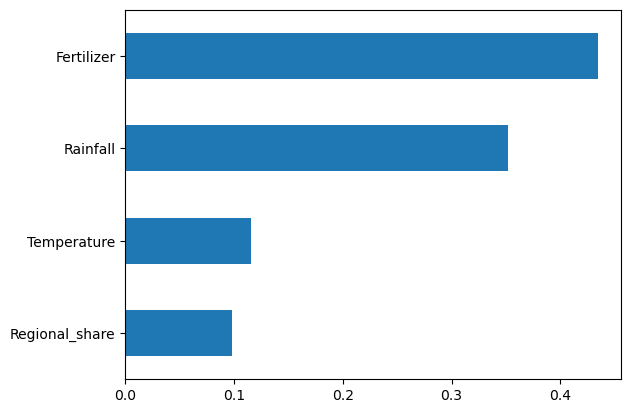

In [28]:
mae = mean_absolute_error(y_test_1, gb_predictions_1)
rmse = np.sqrt(mean_squared_error(y_test_1, gb_predictions_1))
r2 = r2_score(y_test_1, gb_predictions_1)

print(f"--- Gradient Boosting Performance gb_1---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse/1000:.2f} kg/ha")
print(f"MAE: {mae/1000:.2f} kg/ha")

print("\n--- Model Summary: Feature Importance gb_1---")
importances = pd.Series(gb_model_1.feature_importances_, index=features_1)
print(importances.sort_values(ascending=False))

print(f"\nFinal Training Deviance: {gb_model_1.train_score_[-1]:.4f}")
plt.figure()
importances = pd.Series(gb_model_1.feature_importances_, index=gb_model_1.feature_names_in_)
importances.sort_values().plot(kind='barh') # title='Feature Importance Summary using Gradient Boosting model')
#plt.savefig('feature_important_GB.png')
plt.savefig('feature_important.png', bbox_inches = 'tight', dpi = 300)
plt.show()

#### Computer for the SHAP and plotting it for the first gradient model.

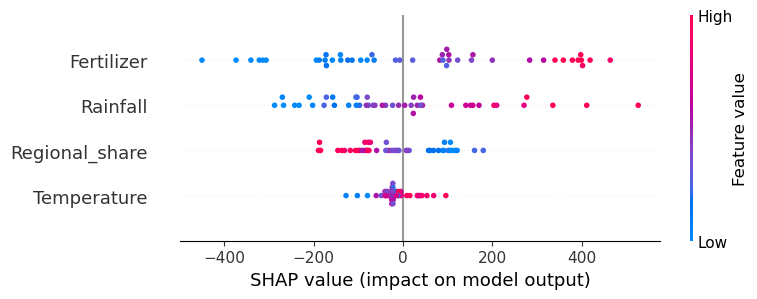

In [29]:
explainer = shap.TreeExplainer(gb_model_1)
shap_values = explainer.shap_values(X_test_1)

plt.figure()
#plt.title("SHAP Summary Plot using Gradient Boosting model")
shap.summary_plot(shap_values, X_test_1, feature_names=features_1, show=False)
#plt.savefig('SHAP_summary.png', bbox_inches = 'tight', dpi = 300)
plt.show()

#### Plotting the parital dependence plots using the first gradient boosting model.

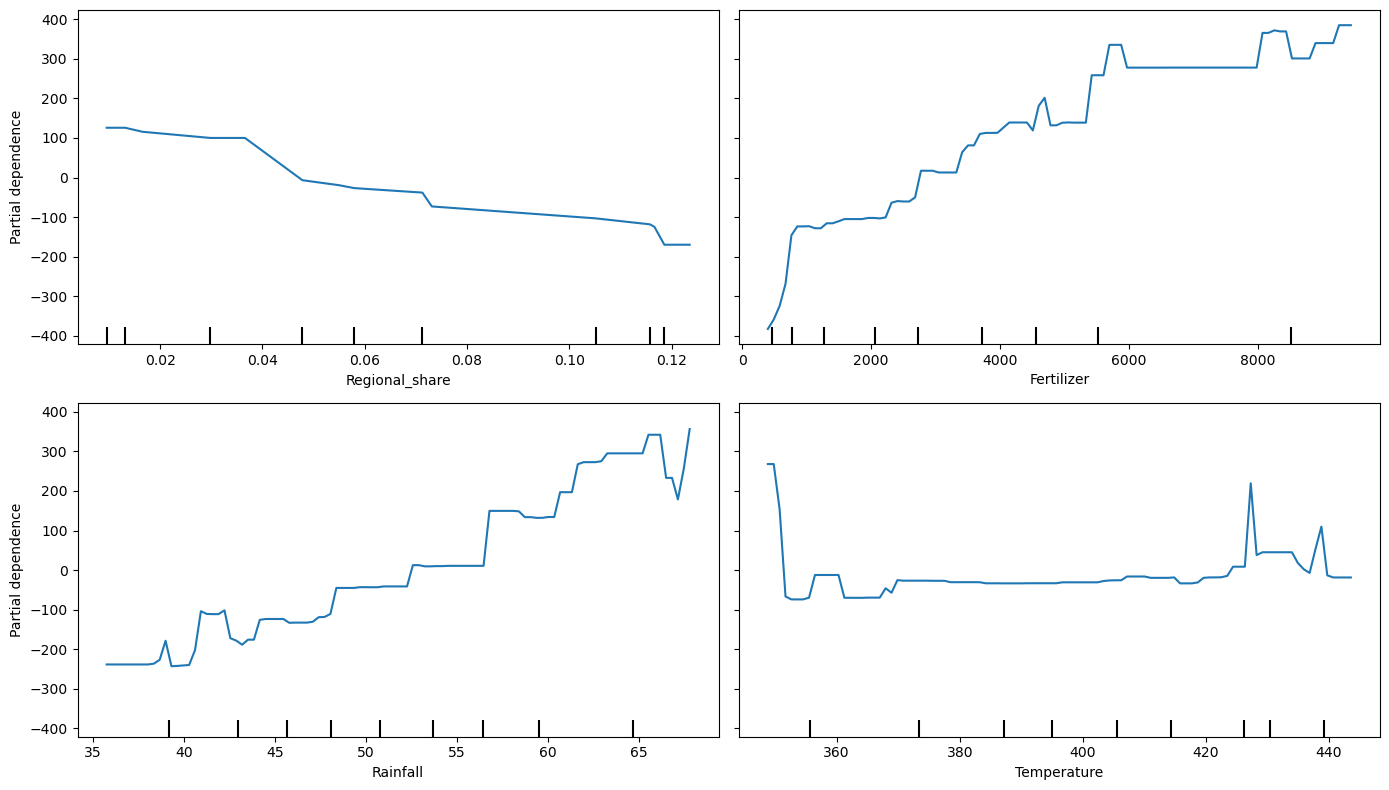

In [30]:
fig, ax = plt.subplots(2,2, figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(
    gb_model_1, 
    X_train_1, 
    features_1, 
    kind="average",
    ax=ax
)

# plt.suptitle("Partial Dependence Plots (Yield kg/ha) using Gradient Boosting model")
plt.tight_layout()
plt.savefig('partial_dependence_plot_GB.png')
plt.show()

# SECTION 9.

#### Calling Ghana maize and setting features for fitting linear mixed model.

In [31]:
dak = pd.read_csv('Ghana_Maize_2023.csv')
dak = dak.dropna(subset=['Area', 'Fertilizer', 'Rainfall', 'Yield_kg_per_ha', 'Temperature'])
features = ['Area(ha)' ,'Fertilizer', 'Rainfall', 'Temperature']
actual = dak['Yield_kg_per_ha']

### Fitting linear mixed model.

#### Fitting linear mixed model including area as a predictor.

In [32]:
LMM_1 = smf.mixedlm("Yield_kg_per_ha ~ 0 + Area + Fertilizer + Rainfall + Temperature ",
                    data=dak,
                    groups="Regional_share")
result_1 = LMM_1.fit()
print(result_1.summary())
lmm_pred_1 = result_1.fittedvalues

             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Yield_kg_per_ha
No. Observations:  224      Method:              REML           
No. Groups:        16       Scale:               38493.2186     
Min. group size:   14       Log-Likelihood:      -1526.7224     
Max. group size:   14       Converged:           Yes            
Mean group size:   14.0                                         
----------------------------------------------------------------
                     Coef.   Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Area                  -0.002    0.001 -1.837 0.066 -0.005  0.000
Fertilizer             0.122    0.010 12.493 0.000  0.103  0.141
Rainfall              26.681    1.556 17.150 0.000 23.632 29.730
Temperature            1.237    0.257  4.815 0.000  0.733  1.740
Regional_share Var 24487.392   71.837                           



#### Fitting linear mixed model excluding are harvested as a feature.

In [33]:
LMM_2 = smf.mixedlm("Yield_kg_per_ha ~ 0 + Fertilizer + Rainfall  + Temperature",
                    data=dak,
                    groups="Regional_share")
result_2 = LMM_2.fit()
print(result_2.summary())
lmm_pred_2 = result_2.fittedvalues

             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Yield_kg_per_ha
No. Observations:  224      Method:              REML           
No. Groups:        16       Scale:               37222.0837     
Min. group size:   14       Log-Likelihood:      -1522.1215     
Max. group size:   14       Converged:           Yes            
Mean group size:   14.0                                         
----------------------------------------------------------------
                     Coef.   Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Fertilizer             0.113    0.008 14.153 0.000  0.097  0.129
Rainfall              25.994    1.576 16.490 0.000 22.905 29.084
Temperature            1.015    0.229  4.431 0.000  0.566  1.464
Regional_share Var 46301.508  102.872                           



#### Computing the metric of the second fitted lmm.

In [34]:
rmse = np.sqrt(mean_squared_error(actual, lmm_pred_2))
mae = mean_absolute_error(actual, lmm_pred_2)
r2_lmm_2 = r2_score(actual, lmm_pred_2)

print(f"--- LMM Performance LMM_2 ---")
print(f"R-squared: {r2_lmm_2:.4f}")
print(f"Actual Scale RMSE: {rmse/1000:.2f} kg/ha")
print(f"Actual Scale MAE: {mae/1000:.2f} kg/ha")

--- LMM Performance LMM_2 ---
R-squared: 0.7392
Actual Scale RMSE: 0.19 kg/ha
Actual Scale MAE: 0.15 kg/ha


#### Ploting the second fitted lmm.

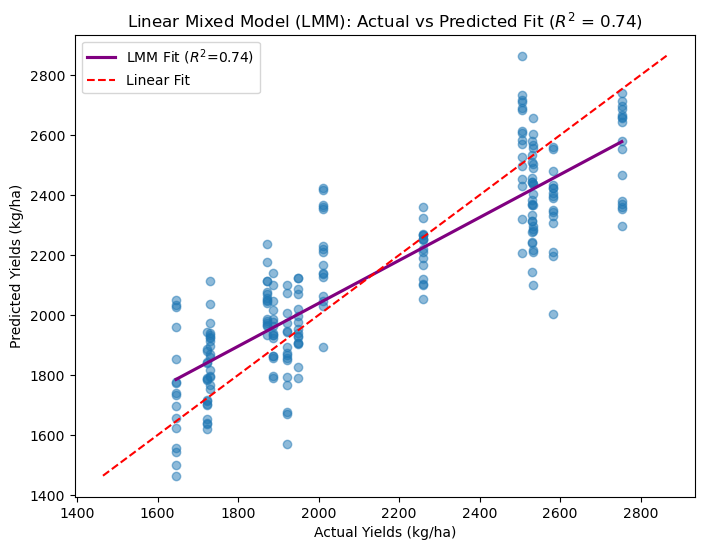

In [35]:
plt.figure(figsize=(8, 6))
sns.regplot(x=actual, y=lmm_pred_2, 
            scatter_kws={'alpha':0.5}, 
            line_kws={'color':'purple', 'label':f'LMM Fit ($R^2$={r2_lmm_2:.2f})'},
           ci = None)

all_vals = np.concatenate([actual, lmm_pred_2])
plt.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()], 
         color='red', linestyle='--', label='Linear Fit')

plt.xlabel('Actual Yields (kg/ha)')
plt.ylabel('Predicted Yields (kg/ha)')
plt.title(f'Linear Mixed Model (LMM): Actual vs Predicted Fit ($R^2$ = {r2_lmm_2:.2f})')
plt.legend()
plt.show()

### Regional contribution check.

In [36]:
model = smf.mixedlm("Yield_kg_per_ha ~ Fertilizer + Rainfall + Temperature", 
                    data=dak, 
                    groups=dak["region"])
result = model.fit()

re_dict = result.random_effects
regional_data = {region: val.iloc[0] for region, val in re_dict.items()}
regional_contributions = pd.DataFrame.from_dict(regional_data, orient='index', columns=['Regional_Contribution'])
regional_contributions.index.name = 'region'
print(regional_contributions.sort_values(by='Regional_Contribution', ascending=False))

               Regional_Contribution
region                              
Greater Accra             539.821849
Savannah                  319.892365
Bono                      103.869070
Ahafo                      92.643492
Western North              74.950052
Western                    67.560626
Upper West                 41.929266
North East                  6.077477
Bono East                  -0.867553
Volta                     -68.877702
Oti                       -75.296610
Central                   -78.379409
Upper East               -166.825475
Eastern                  -234.558976
Northern                 -269.391117
Ashanti                  -352.547356


#### Ecological contribution check.

In [37]:
aez_mapping = {
    'Northern': 'Guinea Savannah', 'Savannah': 'Guinea Savannah', 'North East': 'Guinea Savannah',
    'Upper West': 'Sudan Savannah', 'Upper East': 'Sudan Savannah',
    'Bono': 'Transition', 'Bono East': 'Transition', 'Ahafo': 'Transition',
    'Ashanti': 'Deciduous Forest', 'Eastern': 'Deciduous Forest', 'Western North': 'Deciduous Forest', 'Oti': 'Deciduous Forest',
    'Western': 'Rain Forest', 'Central': 'Rain Forest', 'Volta': 'Rain Forest',
    'Greater Accra': 'Coastal Savannah'
}

dak['AEZ'] = dak['region'].map(aez_mapping)
model = smf.mixedlm("Yield_kg_per_ha ~ Fertilizer + Rainfall + Temperature", 
                    data=dak, 
                    groups=dak["AEZ"])
result = model.fit()

re_dict = result.random_effects
regional_data = {region: val.iloc[0] for region, val in re_dict.items()}
regional_contributions = pd.DataFrame.from_dict(regional_data, orient='index', columns=['Ecological_Contribution'])
regional_contributions.index.name = 'region'
print(regional_contributions.sort_values(by='Ecological_Contribution', ascending=False))

                  Ecological_Contribution
region                                   
Coastal Savannah               337.512826
Guinea Savannah                 15.197027
Transition                     -32.141347
Sudan Savannah                 -32.821510
Rain Forest                   -102.665584
Deciduous Forest              -185.081413


#### Intraclass Correlation Coefficient check.

In [38]:
fe = result_2.fe_params.values      # convert to numpy array
se = result_2.bse_fe.values          # convert to numpy array
re_var = result_2.cov_re.iloc[0, 0]   # random intercept variance (σ²_u)
resid_var = result_2.scale

icc = re_var / (re_var + resid_var)
print(f" Random effect : {re_var:.3f}")
print(f" Fixed effect : {resid_var:.3f}")
print(f"\nIntraclass Correlation (ICC): {icc:.3f}")
print(f"which is  {icc * 100:.1f}% of the total variance in yield is due to differences between regions.")

 Random effect : 46301.508
 Fixed effect : 37222.084

Intraclass Correlation (ICC): 0.554
which is  55.4% of the total variance in yield is due to differences between regions.


# SECTION 10.

#### Fitting lmm with splitted data.

In [39]:
train_df = X_train_1.copy()
train_df['Yield_kg_per_ha'] = y_train_1
test_df = X_test_1.copy()
test_df['Yield_kg_per_ha'] = y_test_1


lmm_3 = smf.mixedlm("Yield_kg_per_ha ~ 0 + Fertilizer + Rainfall  + Temperature" ,
                    train_df, 
                    groups=train_df["Regional_share"])
result_3 = lmm_3.fit()

lmm_pred_3 = result_3.predict(test_df)
rmse = np.sqrt(mean_squared_error(y_test_1, lmm_pred_3))
r2_lmm_3 = r2_score(y_test_1, lmm_pred_3)
mae = mean_absolute_error(y_test_1, lmm_pred_3)
print(f"--- LMM Performance for comparison ---")
print(f"R-squared: {r2_lmm_3:.4f}")
print(f"Actual Scale RMSE: {rmse/1000:.2f} kg/ha")
print(f"Actual Scale MAE: {mae/1000:.2f} kg/ha")

--- LMM Performance for comparison ---
R-squared: 0.5124
Actual Scale RMSE: 0.27 kg/ha
Actual Scale MAE: 0.22 kg/ha


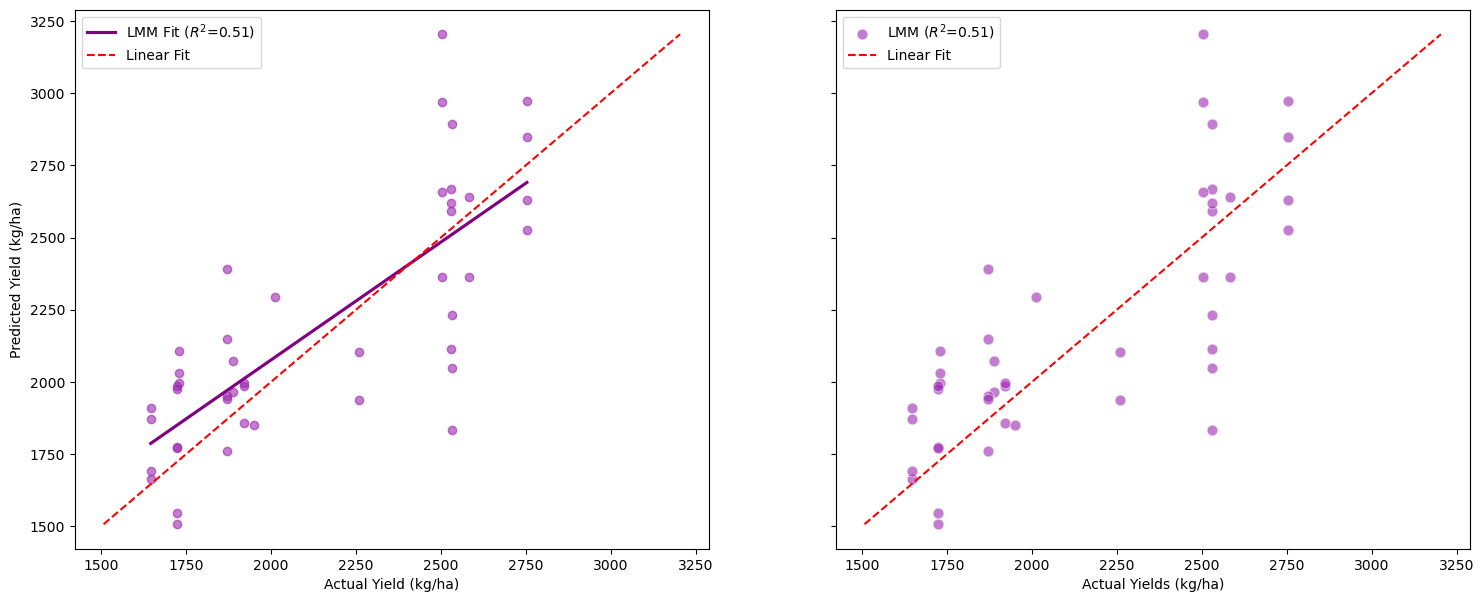

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.regplot(x=y_test_1, y=lmm_pred_3, ax=ax1,
            scatter_kws={'alpha':0.6}, color="#9C27B0",
            line_kws={'color':'purple', 'label':f'LMM Fit ($R^2$={r2_lmm_3:.2f})' },
           ci = None)


all_vals = np.concatenate([y_test_1, lmm_pred_3])
ax1.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
         color='red', linestyle='--', label='Linear Fit')


ax1.set_xlabel('Actual Yield (kg/ha)')
ax1.set_ylabel('Predicted Yield (kg/ha)')
ax1.legend()


sns.scatterplot(x=y_test_1, y=lmm_pred_3, ax=ax2,
                alpha=0.6, color="#9C27B0", s=60, label=f'LMM ($R^2$={r2_lmm_3:.2f})')


all_vals = np.concatenate([y_test_1, lmm_pred_3])
ax2.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
         color='red', linestyle='--', label='Linear Fit')

ax2.set_xlabel('Actual Yields (kg/ha)')
ax2.set_yticklabels([])
ax2.set_ylabel('')
ax2.legend()
#plt.tight_layout()
plt.savefig('LMM_r=0.51.png')
plt.show()

# SECTION 11. 

#### The three models.

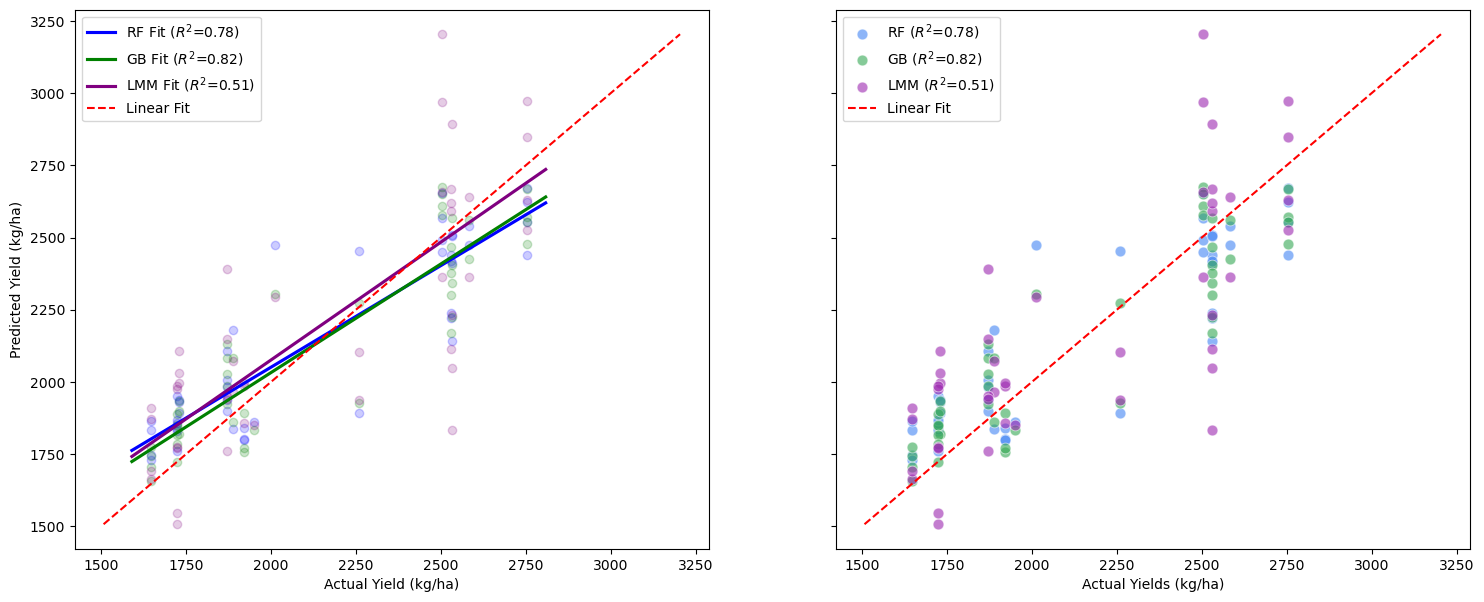

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors = ["#4285F4", "#34A853", "#9C27B0"]

# Random Forest
sns.regplot(x=y_test_1, y=rf_predictions_1, ax=ax1,
            ci=None, truncate=False,
            scatter_kws={'alpha':0.2, 'color':'blue'}, 
            line_kws={'color':'blue', 'label': f'RF Fit ($R^2$={r2_rf:.2f})'})

# Gradient Boosting
sns.regplot(x=y_test_1, y=gb_predictions_1, ax=ax1,
            ci=None, truncate=False,
            scatter_kws={'alpha':0.2, 'color':'green'}, 
            line_kws={'color':'green', 'label': f'GB Fit ($R^2$={r2_gb:.2f})'})

# Linear Mixed Model
sns.regplot(x=y_test_1, y=lmm_pred_3, ax=ax1,
            ci=None, truncate=False,
            scatter_kws={'alpha':0.2, 'color':'purple'}, 
            line_kws={'color':'purple', 'label': f'LMM Fit ($R^2$={r2_lmm_3:.2f})'})


all_vals = np.concatenate([y_test_1, rf_predictions_1, gb_predictions_1, lmm_pred_3])
ax1.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()],
         color='red', linestyle='--', label='Linear Fit')

ax1.set_xlabel('Actual Yield (kg/ha)')
ax1.set_ylabel('Predicted Yield (kg/ha)')
ax1.legend()


sns.scatterplot(x=y_test_1, y=rf_predictions_1, ax=ax2,
                alpha=0.6, color=colors[0], s=60, label=f'RF ($R^2$={r2_rf:.2f})')
sns.scatterplot(x=y_test_1, y=gb_predictions_1, ax=ax2,
                alpha=0.6, color=colors[1], s=60, label=f'GB ($R^2$={r2_gb:.2f})')
sns.scatterplot(x=y_test_1, y=lmm_pred_3, ax=ax2,
                alpha=0.6, color=colors[2], s=60, label=f'LMM ($R^2$={r2_lmm_3:.2f})')

min_v, max_v = all_vals.min(), all_vals.max()
ax2.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', label='Linear Fit')

ax2.set_xlabel('Actual Yields (kg/ha)')
ax2.set_yticklabels([])
ax2.set_ylabel('')
ax2.legend()
#plt.tight_layout()
plt.savefig('Three models.png')
plt.show()

# SECTION 12.

In [42]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(dak, groups=dak['Regional_share']))
train_data = dak.iloc[train_idx]
test_data = dak.iloc[test_idx]

model = smf.mixedlm("Yield_kg_per_ha ~ 0 + Fertilizer + Rainfall  + Temperature",
                    train_data, 
                    groups=train_data["Regional_share"])
result = model.fit()

test_predictions = result.predict(test_data)
test_data = test_data.copy()
test_data['predicted_y'] = test_predictions
print(test_data[['Regional_share', 'Yield_kg_per_ha', 'predicted_y']].head())

   Regional_share  Yield_kg_per_ha  predicted_y
0        0.009563      1887.419088  1905.709397
1        0.009563      1645.838403  1925.563784
2        0.009563      1871.153257  1930.426799
3        0.009563      1724.032912  1668.950233
4        0.009563      1729.146222  2003.935086


In [43]:
fe = result.fe_params.values      # convert to numpy array
se = result.bse_fe.values          # convert to numpy array
re_var = result.cov_re.iloc[0, 0]   # random intercept variance (σ²_u)
resid_var = result.scale

icc = re_var / (re_var + resid_var)
print(f"\nIntraclass Correlation (ICC): {icc:.3f}")
print(f"which is  {icc * 100:.1f}% of the total variance in yield is due to differences between regions.")


Intraclass Correlation (ICC): 0.532
which is  53.2% of the total variance in yield is due to differences between regions.


In [44]:
predictions = test_predictions
actual = test_data['Yield_kg_per_ha']

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)

print(f"--- Model Performance (Original Units: kg/ha) ---")
print(f"R-squared: {r2:.4f}")
print(f"Actual Scale RMSE: {rmse/1000:.2f} kt")
print(f"Actual Scale MAE: {mae/1000:.2f} kt")

--- Model Performance (Original Units: kg/ha) ---
R-squared: 0.0430
Actual Scale RMSE: 0.36 kt
Actual Scale MAE: 0.29 kt
